In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from google.colab import files
files.upload()

Saving netflix_customer_churn.csv to netflix_customer_churn.csv


{'netflix_customer_churn.csv': b'customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre\na9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action\n49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.7,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi\n4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama\nd3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror\n4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action\nd8079475-5be7-47e9-8782-ceb7ff61395e,58,Female,Standard,13.8,26,Oceania,Mobile,13.99,0,Debit Card,3,0.51,Action\n8e63450a-13d6-4e83-bbb5-6aebde9152cb,48,Other,Basic,13.83,20,Asia,TV,8.99,0,Gift Card,5,0.66,Romance\n02387681-8c42-462a-807a-de0168c73b38,51,Male,Basic,1

In [ ]:
df = pd.read_csv('netflix_customer_churn.csv')
df.columns = df.columns.str.strip()

df['avg_watch_time_per_day'] = pd.to_numeric(df['avg_watch_time_per_day'], errors='coerce')
df.loc[df['avg_watch_time_per_day'] > 10, 'avg_watch_time_per_day'] /= 10

# Binary target
df['Churn_bin'] = df['churned']

No missing values found in the DataFrame.


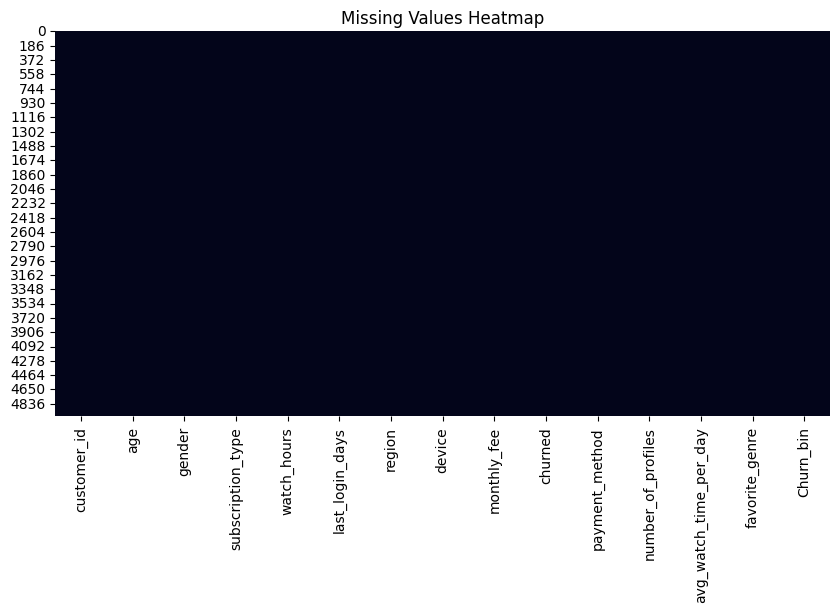

In [ ]:
missing = df.isnull().sum() / len(df) * 100
missing = missing[missing > 0].sort_values()

if not missing.empty:
    plt.figure(figsize=(8, 4))
    missing.plot(kind='barh', color='#e50914')
    plt.axvline(70, color='black', linestyle='--', label='70% threshold')
    plt.title('Figure 1. Missing Data by Column (%)')
    plt.xlabel('Missing %')
    plt.legend()
    plt.tight_layout()
    plt.savefig('fig1_missing.png', dpi=150)
    plt.show()
else:
    print("No missing values found in the DataFrame.")

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


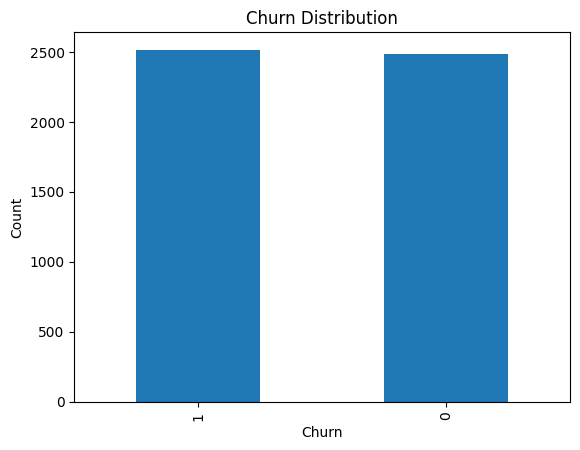

In [ ]:
df["churned"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

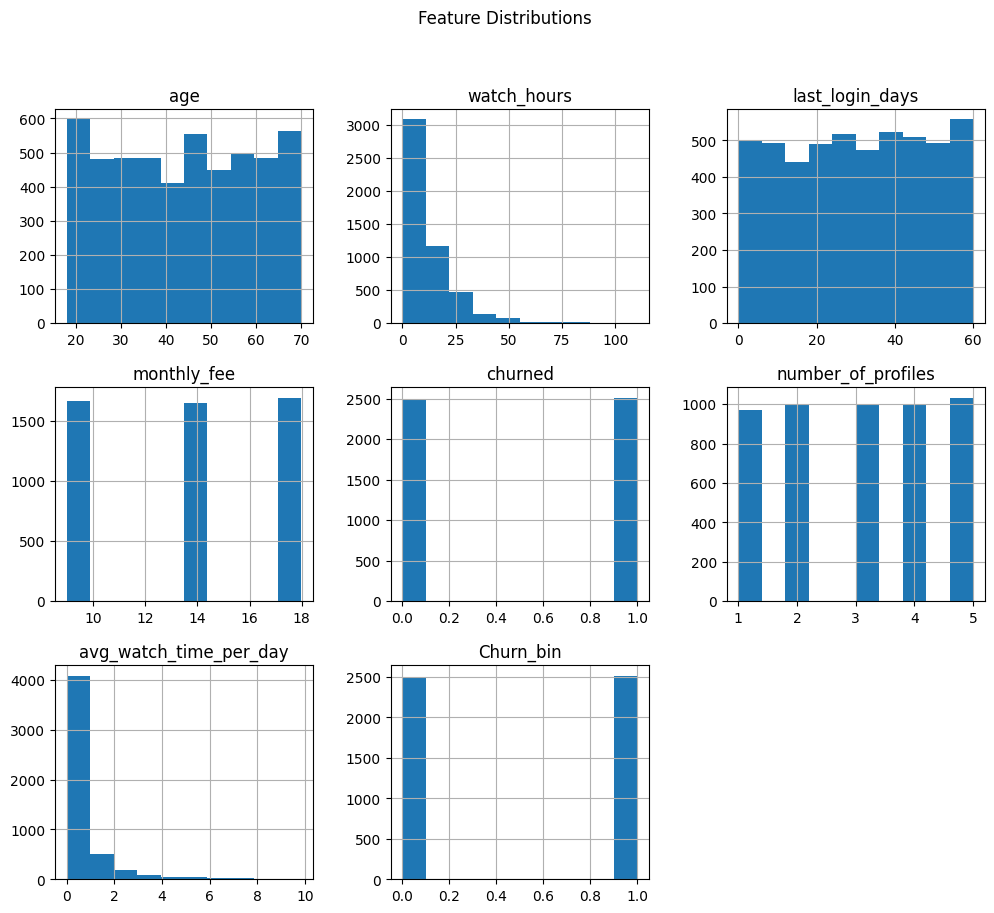

In [ ]:
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

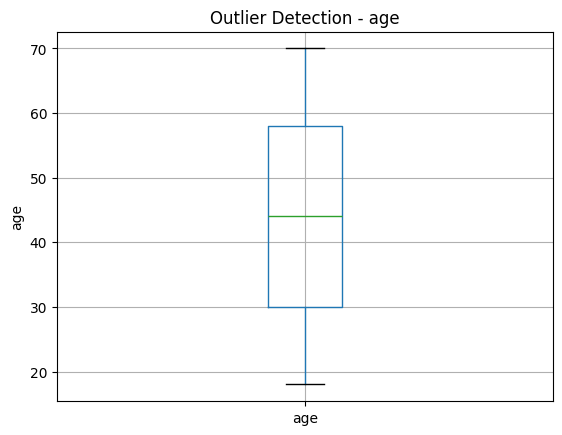

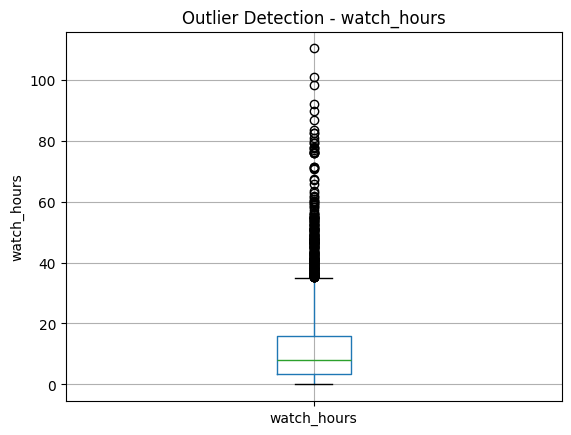

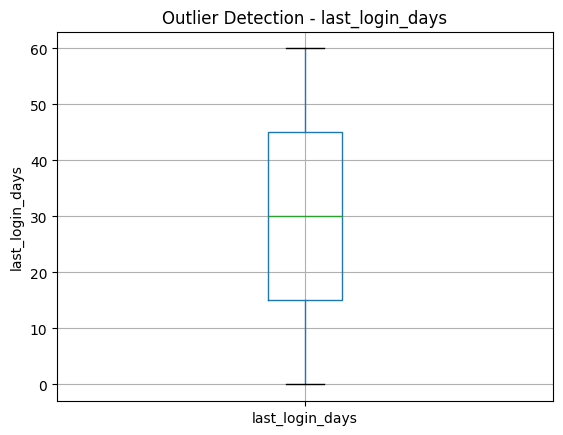

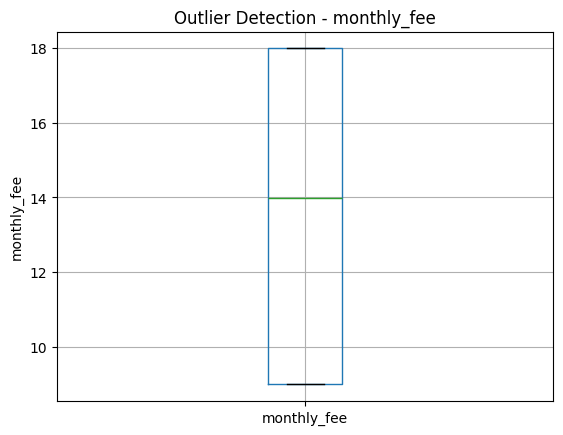

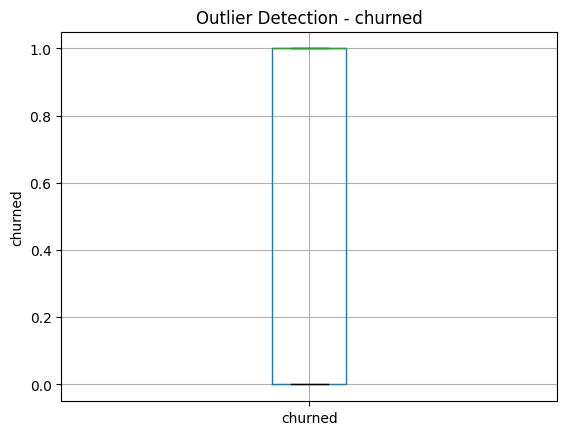

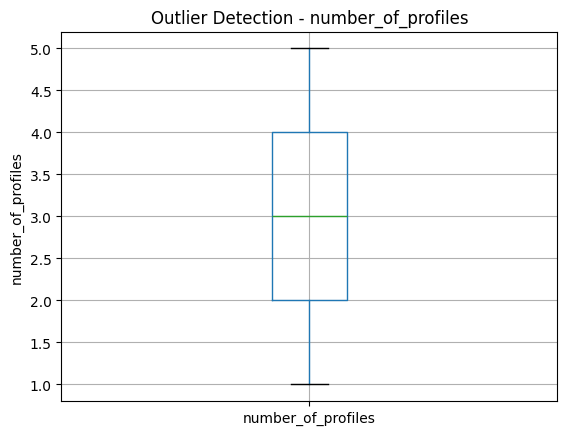

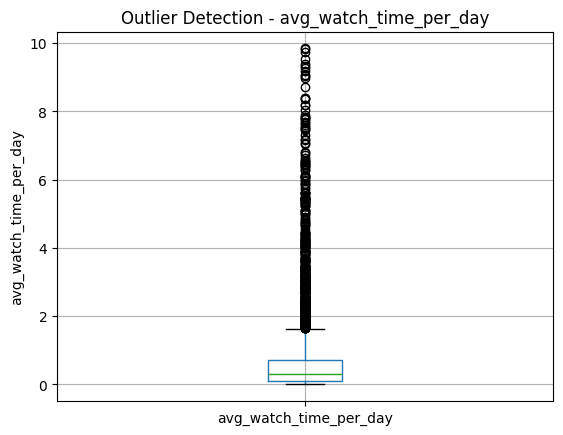

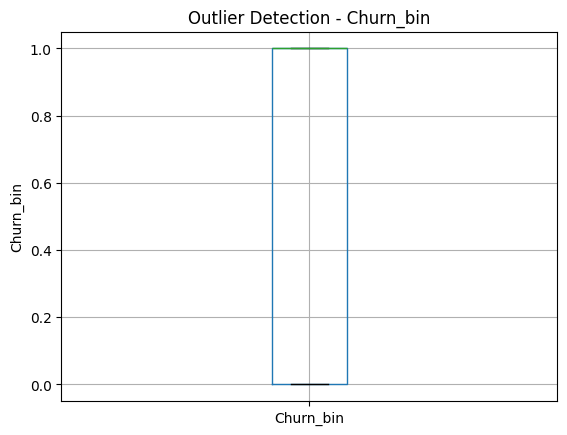

In [ ]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
for col in num_cols:
    plt.figure()
    df.boxplot(column=col)
    plt.title(f"Outlier Detection - {col}")
    plt.ylabel(col)
    plt.show()

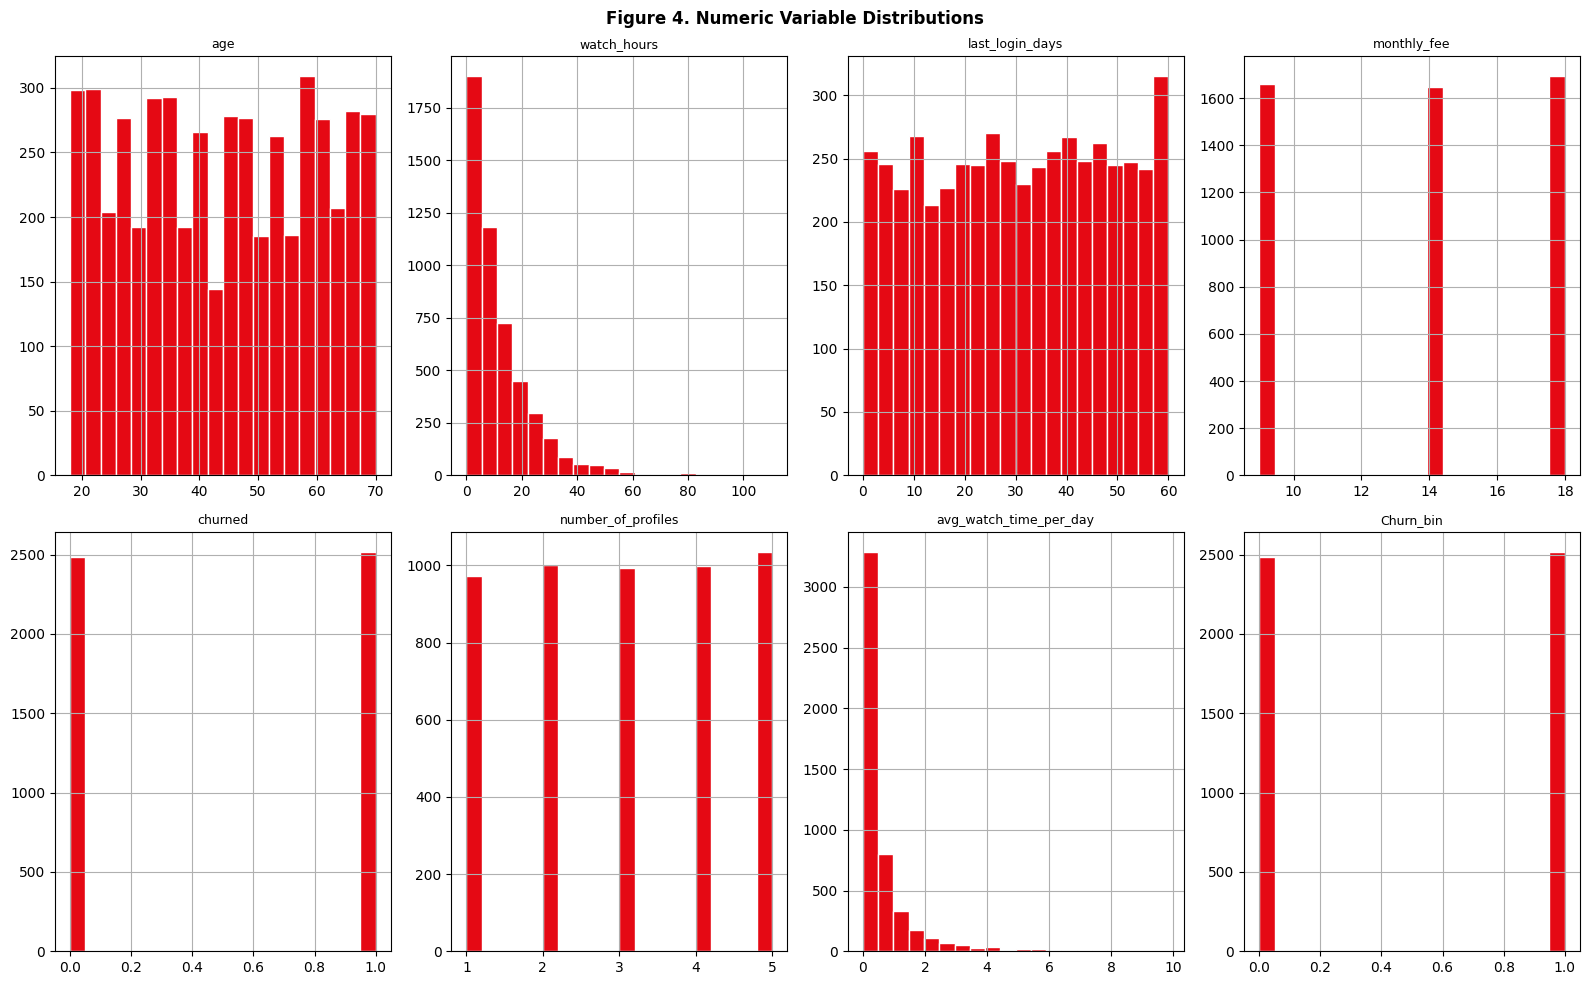

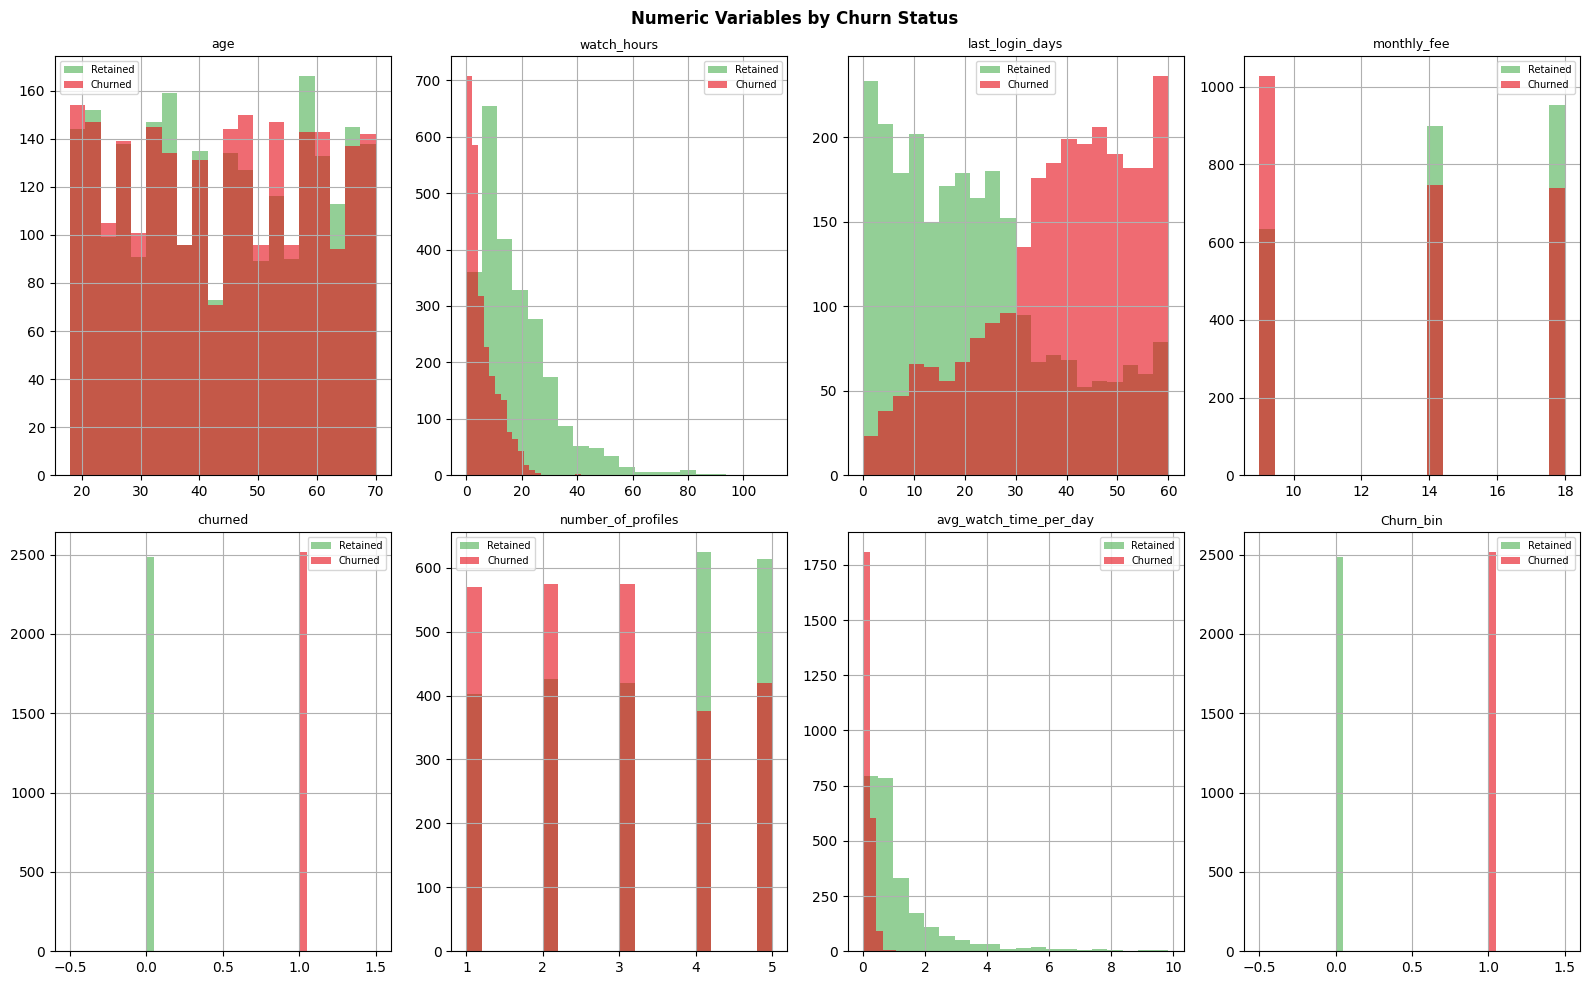

In [ ]:
plt.figure(figsize=(16, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 4, i+1)
    df[col].dropna().hist(bins=20, color='#e50914', edgecolor='white')
    plt.title(col, fontsize=9)
plt.suptitle('Figure 4. Numeric Variable Distributions', fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_histograms.png', dpi=150)
plt.show()


plt.figure(figsize=(16, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 4, i+1)
    df[df['Churn_bin']==0][col].dropna().hist(bins=20, alpha=0.6,
                                               color='#4caf50', label='Retained')
    df[df['Churn_bin']==1][col].dropna().hist(bins=20, alpha=0.6,
                                               color='#e50914', label='Churned')
    plt.title(col, fontsize=9)
    plt.legend(fontsize=7)
plt.suptitle('Numeric Variables by Churn Status', fontweight='bold')
plt.tight_layout()
plt.show()

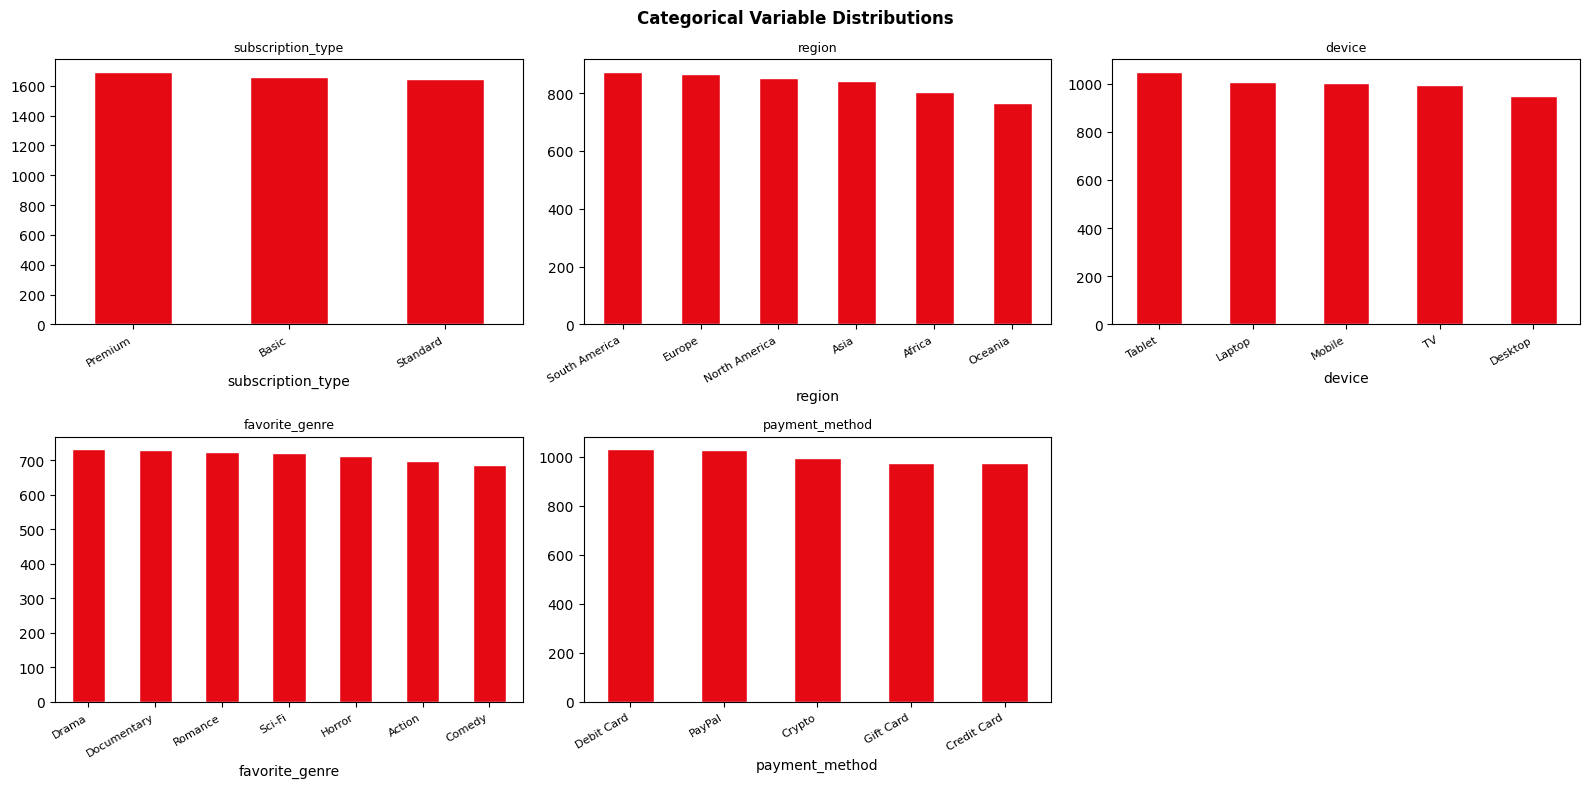

In [ ]:
cat_cols = ['subscription_type', 'region', 'device',
            'favorite_genre', 'payment_method']

plt.figure(figsize=(16, 8))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i+1)
    df[col].str.strip().value_counts().plot(kind='bar', color='#e50914',
                                             edgecolor='white')
    plt.title(col, fontsize=9)
    plt.xticks(rotation=30, ha='right', fontsize=8)
plt.suptitle('Categorical Variable Distributions', fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_categorical.png', dpi=150)
plt.show()

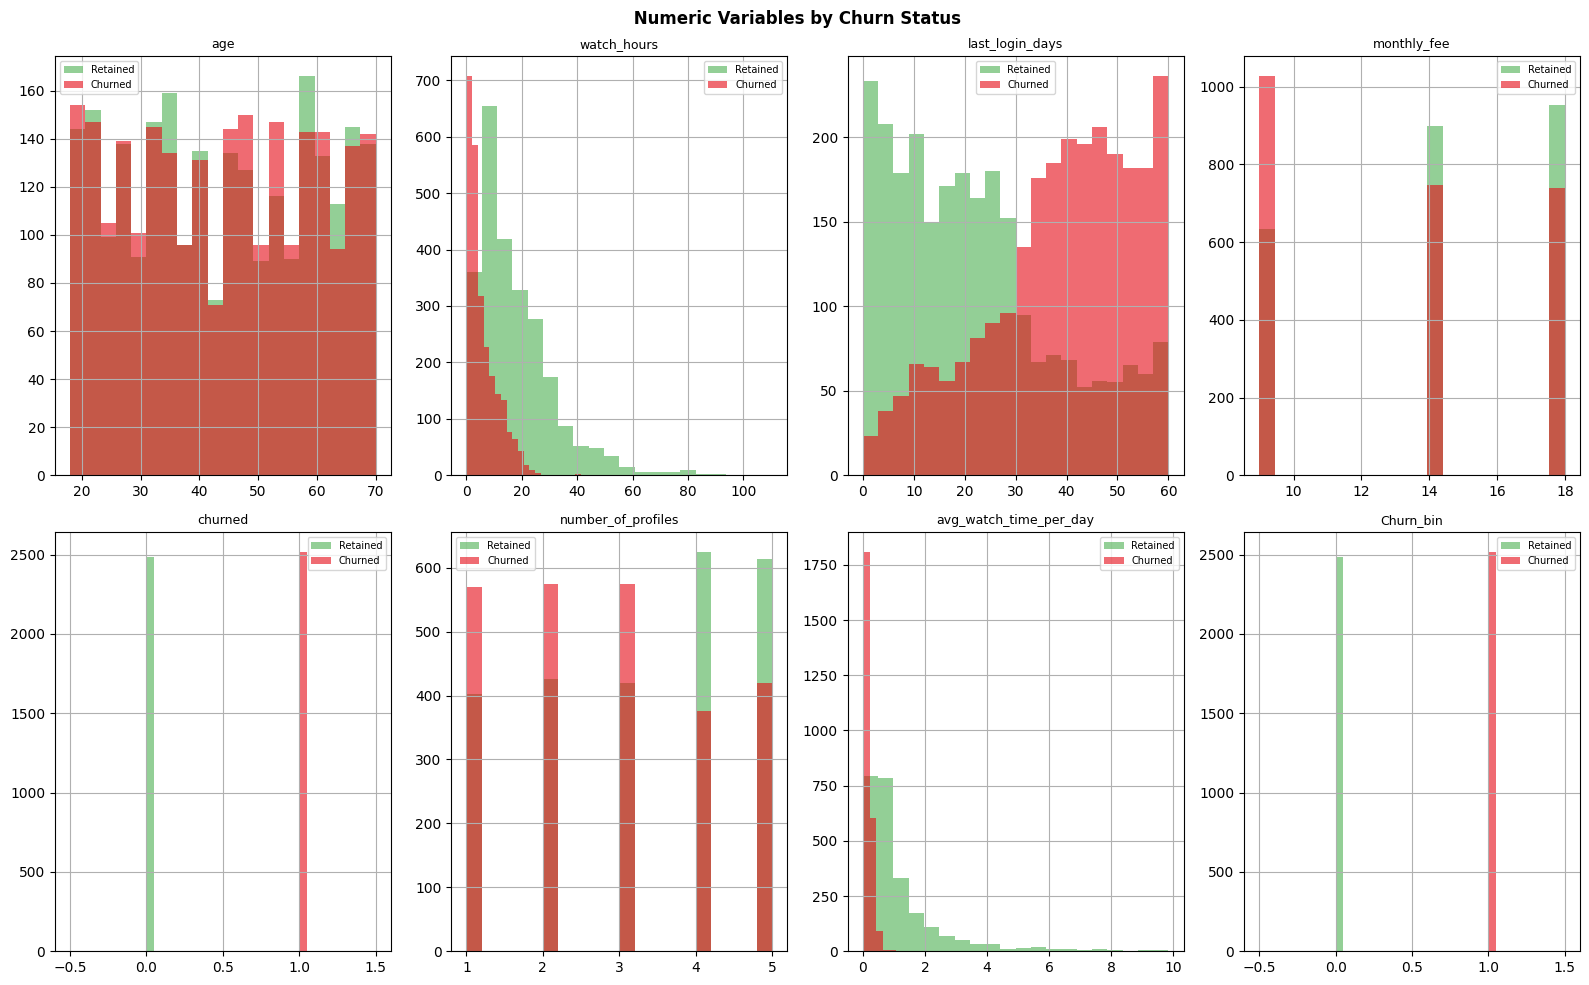

In [ ]:
plt.figure(figsize=(16, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 4, i+1)
    df[df['Churn_bin']==0][col].dropna().hist(bins=20, alpha=0.6,
                                               color='#4caf50', label='Retained')
    df[df['Churn_bin']==1][col].dropna().hist(bins=20, alpha=0.6,
                                               color='#e50914', label='Churned')
    plt.title(col, fontsize=9)
    plt.legend(fontsize=7)
plt.suptitle(' Numeric Variables by Churn Status', fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_numeric_vs_churn.png', dpi=150)
plt.show()

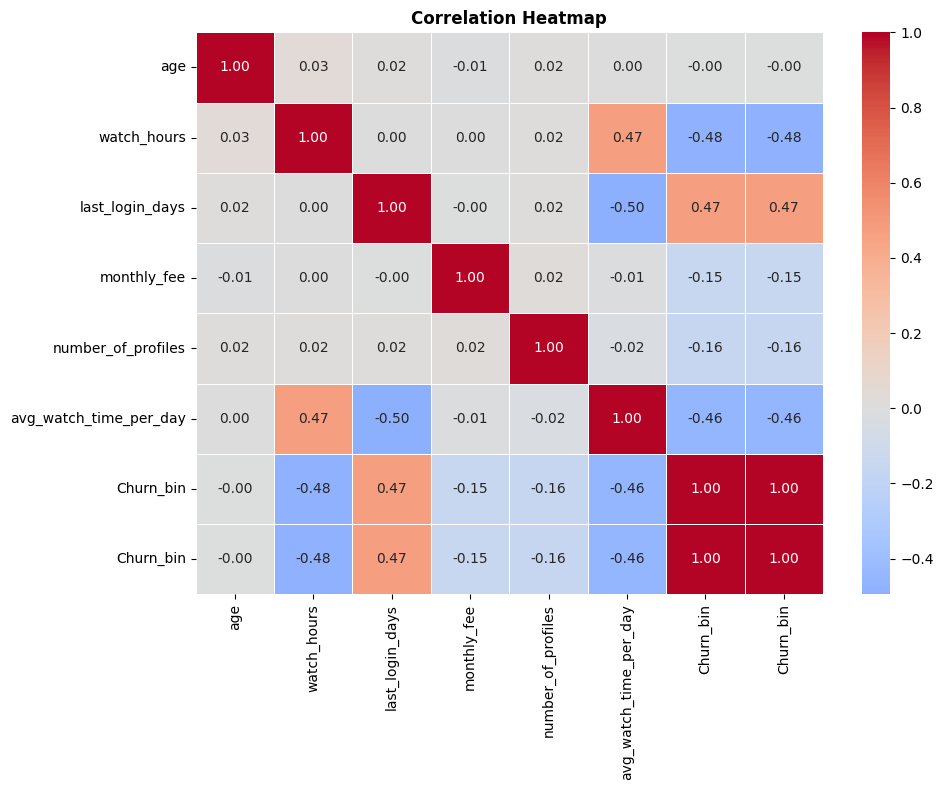

In [ ]:
df['Churn_bin'] = df['churned']
le = LabelEncoder()
df_enc = df.copy()
for col in df_enc.select_dtypes('object').columns:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))
df_enc['Churn_bin'] = df['Churn_bin']

# Redefine num_cols to ensure it contains the correct numeric feature column names
# Exclude 'customer_id' and 'churned' from the features as 'Churn_bin' is the target
num_cols = [col for col in df.select_dtypes(include=["int64", "float64"]).columns
            if col not in ['customer_id', 'churned']]

corr_cols = num_cols + [col for col in df_enc.select_dtypes('object').columns if col != 'customer_id'] + ['Churn_bin']

corr = df_enc[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_heatmap.png', dpi=150)
plt.show()

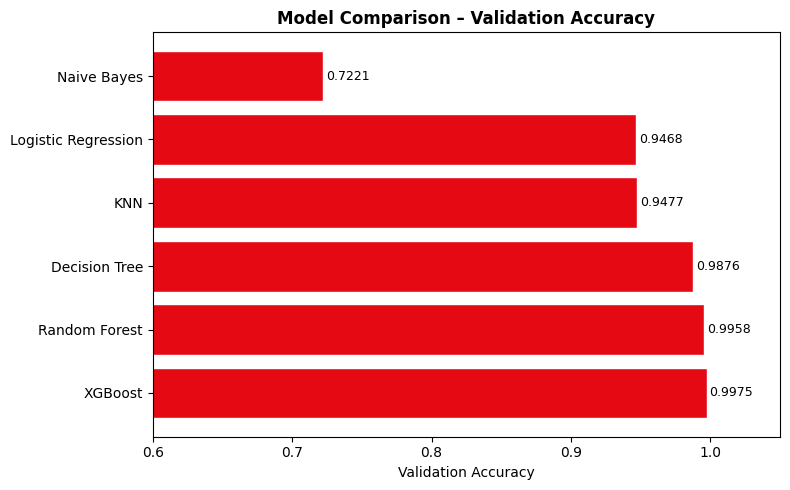

In [ ]:
models  = ['XGBoost', 'Random Forest', 'Decision Tree',
           'KNN', 'Logistic Regression', 'Naive Bayes']
acc     = [0.9975, 0.9958, 0.9876, 0.9477, 0.9468, 0.7221]

plt.figure(figsize=(8, 5))
plt.barh(models, acc, color='#e50914', edgecolor='white')
plt.xlim(0.6, 1.05)
plt.xlabel('Validation Accuracy')
plt.title('Model Comparison – Validation Accuracy', fontweight='bold')
for i, v in enumerate(acc):
    plt.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig9_model_comparison.png', dpi=150)
plt.show()



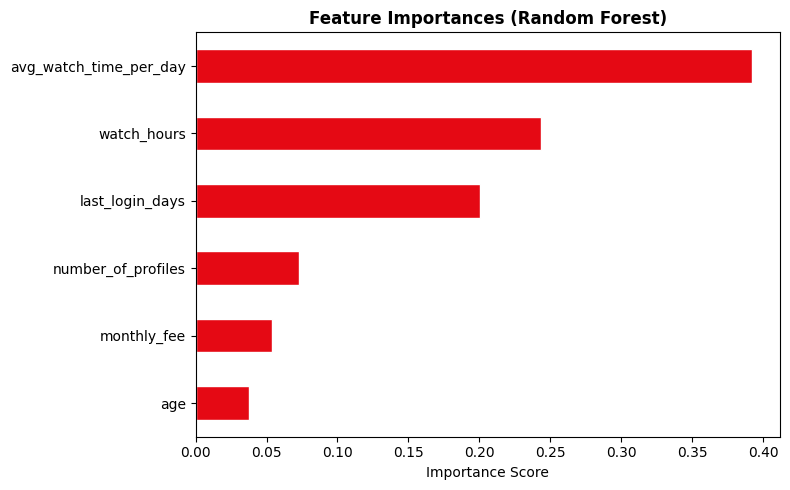

In [ ]:
feature_cols = [c for c in corr_cols if c != 'Churn_bin']
X = df_enc[feature_cols].fillna(df_enc[feature_cols].median())
y = df_enc['Churn_bin']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                            stratify=y, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_tr, y_tr)

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='#e50914', edgecolor='white')
plt.title('Feature Importances (Random Forest)', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('fig10_importances.png', dpi=150)
plt.show()


model training


In [ ]:
# Load data
df = pd.read_csv('netflix_customer_churn.csv')

df.columns = df.columns.str.strip()
df['avg_watch_time_per_day'] = pd.to_numeric(df['avg_watch_time_per_day'], errors='coerce')
df.loc[df['avg_watch_time_per_day'] > 10, 'avg_watch_time_per_day'] /= 10

# Prepare features
X = df.drop(['customer_id', 'churned'], axis=1)
y = df['churned']
le = LabelEncoder()
for col in X.select_dtypes('object').columns:
    X[col] = le.fit_transform(X[col].astype(str))
X = X.fillna(X.median())

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')


Train: 4000 | Test: 1000


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, pred)
tn, fp, fn, tp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]

print('===== LOGISTIC REGRESSION =====')
print(f'                Predicted STAY   Predicted CHURN')
print(f'Actual STAY  |      {tn}        |       {fp}        |')
print(f'Actual CHURN |       {fn}        |      {tp}        |')
print()
print(f'Correct  = {tn} + {tp} = {tn+tp}')
print(f'Wrong    = {fp} + {fn} = {fp+fn}')
print(f'Accuracy = {tn+tp} / 1000 = {accuracy_score(y_test,pred)*100:.2f}%')
print()
print(classification_report(y_test, pred, target_names=['Stayed','Churned']))

===== LOGISTIC REGRESSION =====
                Predicted STAY   Predicted CHURN
Actual STAY  |      429        |       68        |
Actual CHURN |       48        |      455        |

Correct  = 429 + 455 = 884
Wrong    = 68 + 48 = 116
Accuracy = 884 / 1000 = 88.40%

              precision    recall  f1-score   support

      Stayed       0.90      0.86      0.88       497
     Churned       0.87      0.90      0.89       503

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000



In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Train
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, pred)
tn, fp, fn, tp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]

print('===== DECISION TREE =====')
print(f'                Predicted STAY   Predicted CHURN')
print(f'Actual STAY  |      {tn}        |       {fp}        |')
print(f'Actual CHURN |       {fn}        |      {tp}        |')
print()
print(f'Correct  = {tn} + {tp} = {tn+tp}')
print(f'Wrong    = {fp} + {fn} = {fp+fn}')
print(f'Accuracy = {tn+tp} / 1000 = {accuracy_score(y_test,pred)*100:.2f}%')
print()
print(classification_report(y_test, pred, target_names=['Stayed','Churned']))

===== DECISION TREE =====
                Predicted STAY   Predicted CHURN
Actual STAY  |      479        |       18        |
Actual CHURN |       13        |      490        |

Correct  = 479 + 490 = 969
Wrong    = 18 + 13 = 31
Accuracy = 969 / 1000 = 96.90%

              precision    recall  f1-score   support

      Stayed       0.97      0.96      0.97       497
     Churned       0.96      0.97      0.97       503

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, pred)
tn, fp, fn, tp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]

print('===== RANDOM FOREST =====')
print(f'                Predicted STAY   Predicted CHURN')
print(f'Actual STAY  |      {tn}        |       {fp}        |')
print(f'Actual CHURN |       {fn}        |      {tp}        |')
print()
print(f'Correct  = {tn} + {tp} = {tn+tp}')
print(f'Wrong    = {fp} + {fn} = {fp+fn}')
print(f'Accuracy = {tn+tp} / 1000 = {accuracy_score(y_test,pred)*100:.2f}%')
print()
print(classification_report(y_test, pred, target_names=['Stayed','Churned']))

===== RANDOM FOREST =====
                Predicted STAY   Predicted CHURN
Actual STAY  |      486        |       11        |
Actual CHURN |       19        |      484        |

Correct  = 486 + 484 = 970
Wrong    = 11 + 19 = 30
Accuracy = 970 / 1000 = 97.00%

              precision    recall  f1-score   support

      Stayed       0.96      0.98      0.97       497
     Churned       0.98      0.96      0.97       503

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Train
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, pred)
tn, fp, fn, tp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]

print('===== KNN (K=5) =====')
print(f'                Predicted STAY   Predicted CHURN')
print(f'Actual STAY  |      {tn}        |       {fp}        |')
print(f'Actual CHURN |       {fn}        |      {tp}        |')
print()
print(f'Correct  = {tn} + {tp} = {tn+tp}')
print(f'Wrong    = {fp} + {fn} = {fp+fn}')
print(f'Accuracy = {tn+tp} / 1000 = {accuracy_score(y_test,pred)*100:.2f}%')
print()
print(classification_report(y_test, pred, target_names=['Stayed','Churned']))

===== KNN (K=5) =====
                Predicted STAY   Predicted CHURN
Actual STAY  |      426        |       71        |
Actual CHURN |       51        |      452        |

Correct  = 426 + 452 = 878
Wrong    = 71 + 51 = 122
Accuracy = 878 / 1000 = 87.80%

              precision    recall  f1-score   support

      Stayed       0.89      0.86      0.87       497
     Churned       0.86      0.90      0.88       503

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000



In [ ]:
from sklearn.naive_bayes import GaussianNB

# Train
model = GaussianNB()
model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, pred)
tn, fp, fn, tp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]

print('===== NAIVE BAYES =====')
print(f'                Predicted STAY   Predicted CHURN')
print(f'Actual STAY  |      {tn}        |       {fp}        |')
print(f'Actual CHURN |       {fn}        |      {tp}        |')
print()
print(f'Correct  = {tn} + {tp} = {tn+tp}')
print(f'Wrong    = {fp} + {fn} = {fp+fn}')
print(f'Accuracy = {tn+tp} / 1000 = {accuracy_score(y_test,pred)*100:.2f}%')
print()
print(classification_report(y_test, pred, target_names=['Stayed','Churned']))

===== NAIVE BAYES =====
                Predicted STAY   Predicted CHURN
Actual STAY  |      342        |       155        |
Actual CHURN |       14        |      489        |

Correct  = 342 + 489 = 831
Wrong    = 155 + 14 = 169
Accuracy = 831 / 1000 = 83.10%

              precision    recall  f1-score   support

      Stayed       0.96      0.69      0.80       497
     Churned       0.76      0.97      0.85       503

    accuracy                           0.83      1000
   macro avg       0.86      0.83      0.83      1000
weighted avg       0.86      0.83      0.83      1000



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Train
model = GradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, pred)
tn, fp, fn, tp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]

print('===== GRADIENT BOOSTING =====')
print(f'                Predicted STAY   Predicted CHURN')
print(f'Actual STAY  |      {tn}        |       {fp}        |')
print(f'Actual CHURN |       {fn}        |      {tp}        |')
print()
print(f'Correct  = {tn} + {tp} = {tn+tp}')
print(f'Wrong    = {fp} + {fn} = {fp+fn}')
print(f'Accuracy = {tn+tp} / 1000 = {accuracy_score(y_test,pred)*100:.2f}%')
print()
print(classification_report(y_test, pred, target_names=['Stayed','Churned']))

===== GRADIENT BOOSTING =====
                Predicted STAY   Predicted CHURN
Actual STAY  |      494        |       3        |
Actual CHURN |       6        |      497        |

Correct  = 494 + 497 = 991
Wrong    = 3 + 6 = 9
Accuracy = 991 / 1000 = 99.10%

              precision    recall  f1-score   support

      Stayed       0.99      0.99      0.99       497
     Churned       0.99      0.99      0.99       503

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



comparison graph

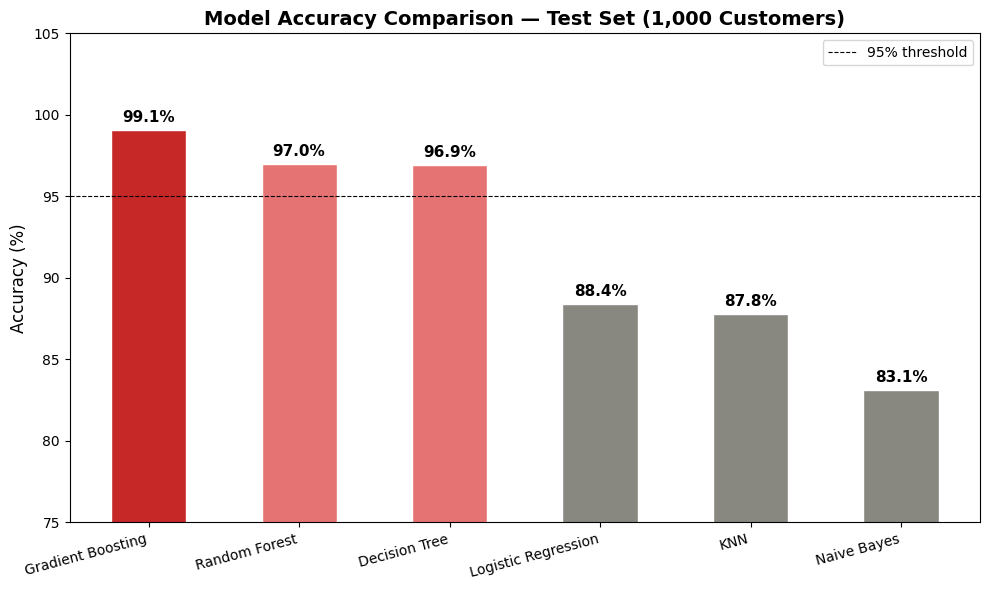

In [ ]:
import matplotlib.pyplot as plt

# Real computed results
models = [
    'Gradient Boosting',
    'Random Forest',
    'Decision Tree',
    'Logistic Regression',
    'KNN',
    'Naive Bayes'
]

accuracy = [99.10, 97.00, 96.90, 88.40, 87.80, 83.10]

colors = ['#C62828', '#E57373', '#E57373', '#888780', '#888780', '#888780']

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracy, color=colors, edgecolor='white', width=0.5)

# Add value labels on top of each bar
for bar, acc in zip(bars, accuracy):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{acc}%',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

# Formatting
plt.ylim(75, 105)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Model Accuracy Comparison — Test Set (1,000 Customers)', fontsize=14, fontweight='bold')
plt.xticks(rotation=15, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.axhline(y=95, color='black', linestyle='--', linewidth=0.8, label='95% threshold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('graph1_accuracy_comparison.png', dpi=150)
plt.show()

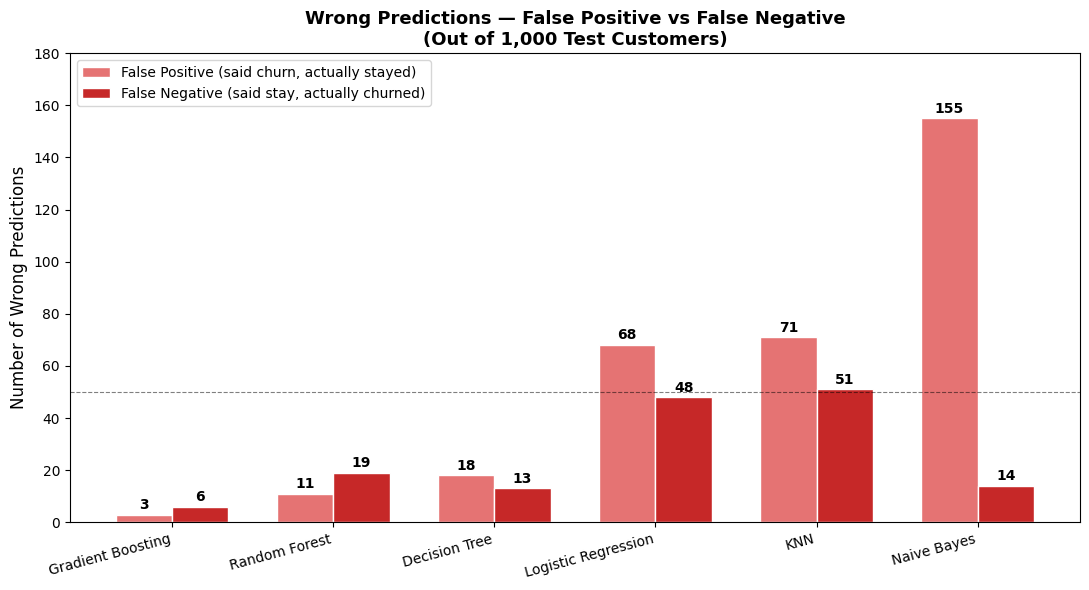

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Real computed results
models = [
    'Gradient Boosting',
    'Random Forest',
    'Decision Tree',
    'Logistic Regression',
    'KNN',
    'Naive Bayes'
]

# From real confusion matrices
false_positive = [3, 11, 18, 68, 71, 155]   # said CHURN but actually STAYED
false_negative = [6, 19, 13, 48, 51, 14]    # said STAY  but actually CHURNED

x = np.arange(len(models))
width = 0.35

# Plot
fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(x - width/2, false_positive, width,
               label='False Positive (said churn, actually stayed)',
               color='#E57373', edgecolor='white')

bars2 = ax.bar(x + width/2, false_negative, width,
               label='False Negative (said stay, actually churned)',
               color='#C62828', edgecolor='white')

# Add value labels on each bar
for bar in bars1:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(int(bar.get_height())),
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

for bar in bars2:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(int(bar.get_height())),
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

# Formatting
ax.set_ylabel('Number of Wrong Predictions', fontsize=12)
ax.set_title('Wrong Predictions — False Positive vs False Negative\n(Out of 1,000 Test Customers)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right', fontsize=10)
ax.legend(fontsize=10)
ax.set_ylim(0, 180)
ax.axhline(y=50, color='black', linestyle='--', linewidth=0.8, alpha=0.5, label='50 errors line')
plt.tight_layout()
plt.savefig('graph2_wrong_predictions.png', dpi=150)
plt.show()

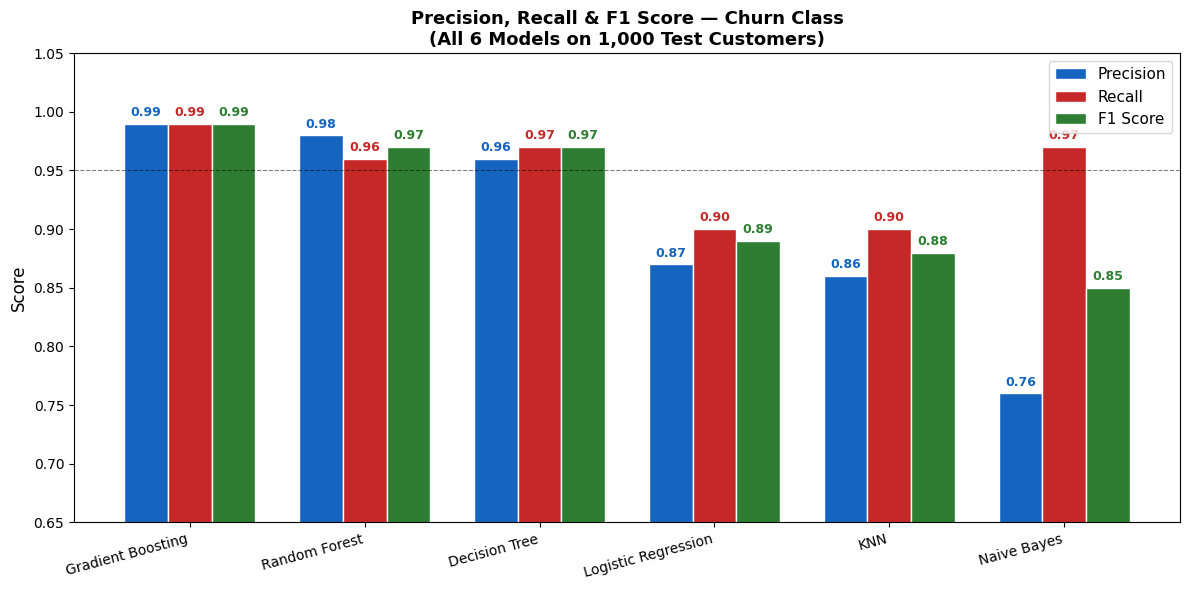

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Real computed results — churn class (class 1)
models = [
    'Gradient Boosting',
    'Random Forest',
    'Decision Tree',
    'Logistic Regression',
    'KNN',
    'Naive Bayes'
]

precision = [0.99, 0.98, 0.96, 0.87, 0.86, 0.76]
recall    = [0.99, 0.96, 0.97, 0.90, 0.90, 0.97]
f1_score  = [0.99, 0.97, 0.97, 0.89, 0.88, 0.85]

x = np.arange(len(models))
width = 0.25

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width,     precision, width,
               label='Precision', color='#1565C0', edgecolor='white')

bars2 = ax.bar(x,             recall,    width,
               label='Recall',    color='#C62828', edgecolor='white')

bars3 = ax.bar(x + width,     f1_score,  width,
               label='F1 Score',  color='#2E7D32', edgecolor='white')

# Add value labels on each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.004,
            f'{bar.get_height():.2f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1565C0')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.004,
            f'{bar.get_height():.2f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='#C62828')

for bar in bars3:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.004,
            f'{bar.get_height():.2f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='#2E7D32')

# Formatting
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision, Recall & F1 Score — Churn Class\n(All 6 Models on 1,000 Test Customers)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right', fontsize=10)
ax.set_ylim(0.65, 1.05)
ax.axhline(y=0.95, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('graph3_precision_recall_f1.png', dpi=150)
plt.show()